In [6]:
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score ,mean_absolute_percentage_error


# 1. Load the dataset
df = pd.read_csv("StudentPerformanceFactors.csv")
df.head()



,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [3]:
X = df.drop(columns=['Exam_Score'])
y = df['Exam_Score']

# 3. Handle Missing Values (Mode Imputation)
X['Teacher_Quality'] = X['Teacher_Quality'].fillna(X['Teacher_Quality'].mode()[0])
X['Parental_Education_Level'] = X['Parental_Education_Level'].fillna(X['Parental_Education_Level'].mode()[0])
X['Distance_from_Home'] = X['Distance_from_Home'].fillna(X['Distance_from_Home'].mode()[0])

print("Missing values after imputation:\n", X.isnull().sum().sum())


Missing values after imputation:
 0


In [4]:
# 4. Define feature columns
ordinal_cols = ['Parental_Involvement', 'Motivation_Level', 'Family_Income', 'Teacher_Quality']
nominal_cols = ['Access_to_Resources', 'Extracurricular_Activities', 'Internet_Access', 
                'School_Type', 'Peer_Influence', 'Learning_Disabilities', 
                'Parental_Education_Level', 'Distance_from_Home', 'Gender']
numeric_cols = ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 
                'Tutoring_Sessions', 'Physical_Activity']

# 5. Define Ordinal Mappings
mapping_order = [
    ['Low', 'Medium', 'High'],      # Parental_Involvement
    ['Low', 'Medium', 'High'],      # Motivation_Level
    ['Low', 'Medium', 'High'],      # Family_Income
    ['Low', 'Medium', 'High']       # Teacher_Quality
]

# 6. Build the Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('ord', OrdinalEncoder(categories=mapping_order), ordinal_cols),
        ('nom', OneHotEncoder(drop='first', sparse_output=False), nominal_cols),
        ('num', StandardScaler(), numeric_cols)
    ])

# split 20%
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 8. Transform Data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [7]:
lin_reg = LinearRegression()
lin_reg.fit(X_train_processed, y_train)

y_pred_lin = lin_reg.predict(X_test_processed)

lin_mae = mean_absolute_error(y_test, y_pred_lin)
lin_mse = mean_squared_error(y_test, y_pred_lin)
lin_rmse = np.sqrt(lin_mse)
lin_r2 = r2_score(y_test, y_pred_lin)
lin_mape = mean_absolute_percentage_error(y_test, y_pred_lin)

# 4. Calculate Adjusted R-squared
# n = number of observations, p = number of predictors (features)
n = len(y_test)
p = X_test_processed.shape[1]
lin_adj_r2 = 1 - ((1 - lin_r2) * (n - 1) / (n - p - 1))

# 5. Print out the full diagnostic report
print("--- COMPREHENSIVE LINEAR REGRESSION METRICS ---")
print(f"Mean Absolute Error (MAE):             {lin_mae:.2f} (Average error in exam points)")
print(f"Mean Squared Error (MSE):              {lin_mse:.2f}")
print(f"Root Mean Squared Error (RMSE):        {lin_rmse:.2f} (Heavily penalizes large errors)")
print(f"Mean Absolute Percentage Error (MAPE): {lin_mape:.2%} (Average percentage error)")
print(f"R-squared (R2 Score):                  {lin_r2:.4f} (Proportion of variance explained)")
print(f"Adjusted R-squared:                    {lin_adj_r2:.4f} (Adjusted for number of features)")

--- COMPREHENSIVE LINEAR REGRESSION METRICS ---
Mean Absolute Error (MAE):             0.45 (Average error in exam points)
Mean Squared Error (MSE):              3.25
Root Mean Squared Error (RMSE):        1.80 (Heavily penalizes large errors)
Mean Absolute Percentage Error (MAPE): 0.62% (Average percentage error)
R-squared (R2 Score):                  0.7702 (Proportion of variance explained)
Adjusted R-squared:                    0.7662 (Adjusted for number of features)


BASELINE SCORE (Intercept): 63.29 points
This is the mathematical starting point before factoring in student behavior.



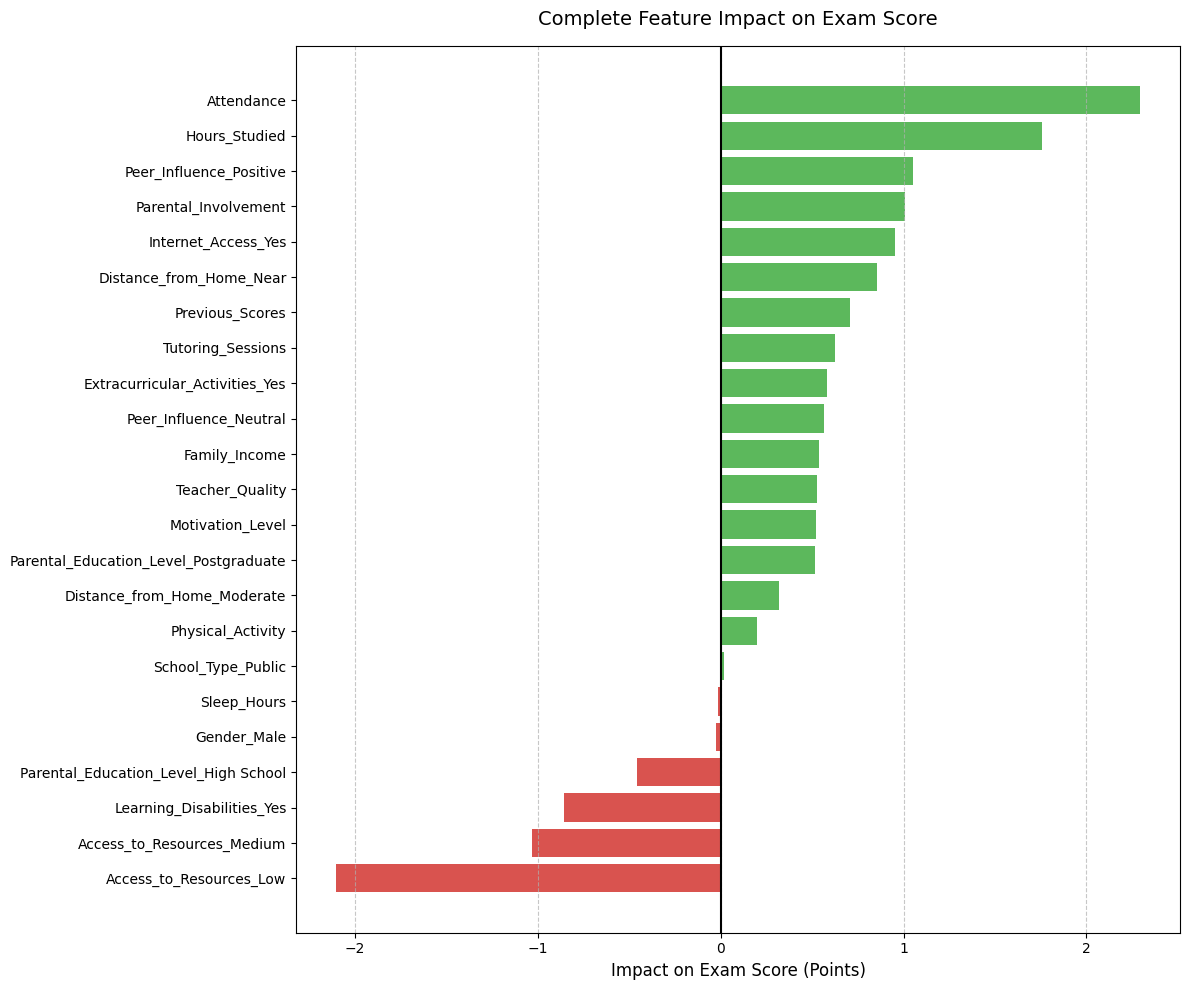

In [9]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Extract the Intercept (Baseline Score)
baseline_score = lin_reg.intercept_
print(f"BASELINE SCORE (Intercept): {baseline_score:.2f} points")
print("This is the mathematical starting point before factoring in student behavior.\n")

# 2. Extract feature names from the preprocessor
ordinal_feature_names = ordinal_cols
nominal_feature_names = preprocessor.named_transformers_['nom'].get_feature_names_out(nominal_cols)
numeric_feature_names = numeric_cols

# Combine all feature names and get coefficients
all_feature_names = np.concatenate([ordinal_feature_names, nominal_feature_names, numeric_feature_names])
coefficients = lin_reg.coef_

# 3. Create a DataFrame for visualization
feature_importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Coefficient': coefficients
})

# Sort by coefficient value (from most negative to most positive)
feature_importance_df = feature_importance_df.sort_values(by='Coefficient')

# 4. Create a Diverging Bar Chart
plt.figure(figsize=(12, 10)) # Made taller to comfortably fit all features

# Color positive impacts green and negative impacts red
colors = ['#d9534f' if x < 0 else '#5cb85c' for x in feature_importance_df['Coefficient']]

plt.barh(feature_importance_df['Feature'], feature_importance_df['Coefficient'], color=colors)

# Chart formatting
plt.title('Complete Feature Impact on Exam Score', fontsize=14, pad=15)
plt.xlabel('Impact on Exam Score (Points)', fontsize=12)
plt.axvline(x=0, color='black', linestyle='-', linewidth=1.5) # Draw the zero line
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()